<a href="https://colab.research.google.com/github/Nestor-Hutasoit/porto-nestor/blob/main/Grade_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Collection

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("aiexplorer77/gaming-vs-academic-performance")

print("Dataset path:", path)
print("Isi folder:", os.listdir(path))


df = pd.read_csv(os.path.join(path, "Gaming_Academic_Performance.csv"))

df.head()

Using Colab cache for faster access to the 'gaming-vs-academic-performance' dataset.
Dataset path: /kaggle/input/gaming-vs-academic-performance
Isi folder: ['Gaming_Academic_Performance.csv']


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [ ]:
#Data Preprocessing

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["gaming_genre"] = le.fit_transform(df["gaming_genre"])

df["gaming_study_ratio"] = df["gaming_hours"] / df["study_hours"].replace(0, 1)

df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gaming_study_ratio
0,1,22,1,7.23,8.78,6.96,91.44,1,3.25,9.36,235.84,14.69,Low,86.459555,0.823462
1,2,19,1,0.07,8.72,7.63,63.63,0,1.02,3.21,328.71,2.47,Medium,98.230000,0.008028
2,3,23,0,1.73,9.56,4.40,83.26,0,3.46,5.56,313.61,4.73,High,90.560000,0.180962
3,4,20,0,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,Low,32.670000,3.940476
4,5,22,0,5.36,5.83,5.55,65.57,1,1.01,8.23,249.31,12.48,Low,58.710000,0.919383


In [ ]:
#Feature Selection
X = df[[
    "age",
    "gender",
    "gaming_hours",
    "study_hours",
    "sleep_hours",
    "social_activity",
    "device_usage",
    "gaming_study_ratio"
]]

y = df["grades"]

print(X.head())
print(y.head())

   age  gender  gaming_hours  study_hours  sleep_hours  social_activity  \
0   22       1          7.23         8.78         6.96             3.25   
1   19       1          0.07         8.72         7.63             1.02   
2   23       0          1.73         9.56         4.40             3.46   
3   20       0          6.62         1.68         7.83             1.46   
4   22       0          5.36         5.83         5.55             1.01   

   device_usage  gaming_study_ratio  
0          9.36            0.823462  
1          3.21            0.008028  
2          5.56            0.180962  
3         11.78            3.940476  
4          8.23            0.919383  
0    86.459555
1    98.230000
2    90.560000
3    32.670000
4    58.710000
Name: grades, dtype: float64


In [ ]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Modelling

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

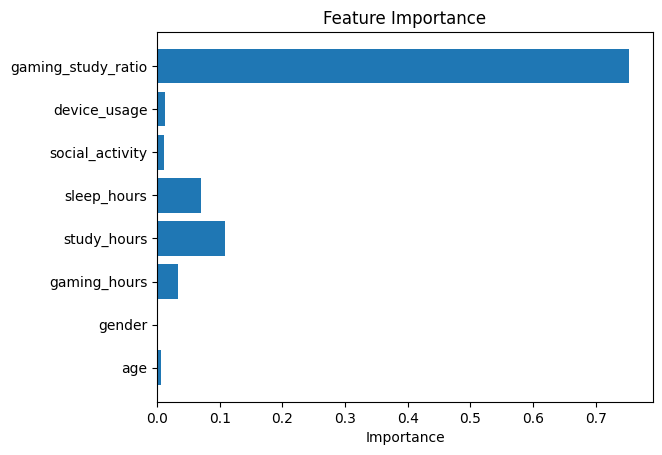

In [ ]:
#Interpretation

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
#Evaluation

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 5.405037565366638
R2: 0.903730713289618


In [ ]:
#Comparison

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT MAE:", mean_absolute_error(y_test, y_pred_dt))
print("DT R2:", r2_score(y_test, y_pred_dt))

DT MAE: 7.688789902270511
DT R2: 0.8107221494474656


In [ ]:
#Contoh Prediksi

def predict_student(data):
    import pandas as pd

    data["gaming_study_ratio"] = data["gaming_hours"] / max(data["study_hours"], 1)

    df_input = pd.DataFrame([data])

    prediction = rf.predict(df_input)[0]

    return prediction

result = predict_student({
    "age": 20,
    "gender": 1,
    "gaming_hours": 4,
    "study_hours": 3,
    "sleep_hours": 7,
    "social_activity": 2,
    "device_usage": 5
})

print("Predicted Grade:", result)

Predicted Grade: 56.14526064103744
